Number of observations: 25
Number of predictors: 8

OUTER LOOCV FOLD 1/25
Training observations = 24
Test observation       = 1
Observed  = 3.510000
Predicted = 2.336654
Best alpha = 0.001

OUTER LOOCV FOLD 2/25
Training observations = 24
Test observation       = 1
Observed  = 1.600000
Predicted = 1.836875
Best alpha = 0.001

OUTER LOOCV FOLD 3/25
Training observations = 24
Test observation       = 1
Observed  = 5.910000
Predicted = 5.251118
Best alpha = 0.001

OUTER LOOCV FOLD 4/25
Training observations = 24
Test observation       = 1
Observed  = 2.010000
Predicted = 0.944248
Best alpha = 0.001

OUTER LOOCV FOLD 5/25
Training observations = 24
Test observation       = 1
Observed  = 5.950000
Predicted = 5.244788
Best alpha = 0.001

OUTER LOOCV FOLD 6/25
Training observations = 24
Test observation       = 1
Observed  = 6.100000
Predicted = 5.221050
Best alpha = 0.001

OUTER LOOCV FOLD 7/25
Training observations = 24
Test observation       = 1
Observed  = 1.490000
Predicted = 2.452806
Be

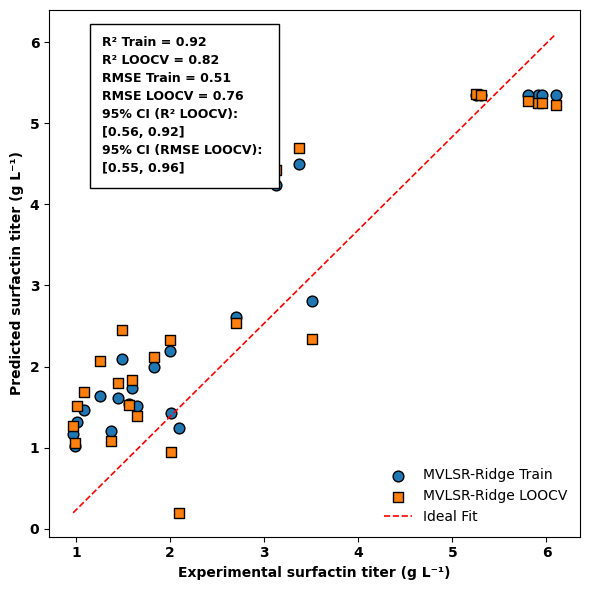

In [22]:

# MVLSR-ridge regression model training and validation using nested LOOCV

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error



# Load data
data = "define datafile path"

df = pd.read_csv(data)

# Select basis functions
X_real = np.column_stack((
    df.TEMP**2,
    df.SPEED**2,
    df.INNOCULUM**2,
    df.TEMP * df.SPEED,
    df.TEMP* df.INNOCULUM,
    df.INNOCULUM * df.SPEED,
    df.TEMP,
    df.SPEED
))

#Target varible
y = df["SURFACTIN"].values


X = np.asarray(X_real)
y = np.asarray(y).ravel()

print("Number of observations:", X.shape[0])
print("Number of predictors:", X.shape[1])



# 2. Outer LOOCV

outer_loo = LeaveOneOut()

# Store prediction for every outer left-out observation
y_pred_LOOCV = np.zeros(len(y))

# Store best alpha from every outer fold
best_alpha = []



# 3. Ridge pipeline

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])



# 4. Hyperparameter grid

param_grid = {
    "ridge__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10    
    ]
}



# 5. Nested LOOCV


for fold, (train_idx, test_idx) in enumerate(
        outer_loo.split(X), start=1):

    print("\n" + "=" * 60)
    print(f"OUTER LOOCV FOLD {fold}/{len(y)}")
    print("=" * 60)


  
    # Outer training data
  

    X_train = X[train_idx]
    y_train = y[train_idx]


    
    # Outer test data
 

    X_test = X[test_idx]
    y_test = y[test_idx]


    print(
        f"Training observations = {len(train_idx)}"
    )

    print(
        f"Test observation       = {len(test_idx)}"
    )


    # Inner LOOCV


    inner_loo = LeaveOneOut()



    # Grid Search using only outer-training data


    grid_search = GridSearchCV(
        estimator=ridge_pipeline,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=inner_loo,
        n_jobs=-1,
        refit=True
    )


 
    # Hyperparameter tuning

    grid_search.fit(
        X_train,
        y_train
    )


 
    # Best ridge model from inner LOOCV


    best_model = grid_search.best_estimator_


  
    # Best lamda for this outer fold


    alpha_fold = grid_search.best_params_[
        "ridge__alpha"
    ]

    best_alpha.append(alpha_fold)


  
    # Predict the outer left-out observation

    prediction = best_model.predict(X_test)[0]

    y_pred_LOOCV[test_idx[0]] = prediction


  
    # Display fold results

    print(
        f"Observed  = {y_test[0]:.6f}"
    )

    print(
        f"Predicted = {prediction:.6f}"
    )

    print(
        f"Best alpha = {alpha_fold}"
    )



# 6. Nested LOOCV performance metrics

R2_LOOCV = r2_score(
    y,
    y_pred_LOOCV
)

RMSE_LOOCV = np.sqrt(
    mean_squared_error(
        y,
        y_pred_LOOCV
    )
)


print("\n")
print("=" * 60)
print("Nested LOOCV performance")
print("=" * 60)

print(
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)



# 7. Final ridge hyperparameter optimization

print("\n")
print("=" * 60)
print("Final ridge hyperparameter optimization")
print("=" * 60)



# Inner LOOCV using all observations

final_inner_loo = LeaveOneOut()


final_grid = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=final_inner_loo,
    n_jobs=-1,
    refit=True
)


final_grid.fit(
    X,
    y
)



# Final optimized Ridge model

final_model = final_grid.best_estimator_


alpha_final = final_grid.best_params_[
    "ridge__alpha"
]


print(
    f"Final optimal alpha = {alpha_final}"
)





# 8. Final ridge training predictions 

# final_model has been fitted using all 25 observations

y_train_pred = final_model.predict(X)



# 9. Training performance metrics


R2_train = r2_score(
    y,
    y_train_pred
)

RMSE_train = np.sqrt(
    mean_squared_error(
        y,
        y_train_pred
    )
)


print("\n")
print("=" * 60)
print("Training performance metrics")
print("=" * 60)

print(
    f"Train R²   = {R2_train:.4f}"
)

print(
    f"Train RMSE = {RMSE_train:.4f}"
)



# 10. Train vs LOOCV comparison


print("\n")
print("=" * 60)
print("Train vs nested LOOCV")
print("=" * 60)

print(
    f"Train R²   = {R2_train:.4f} | "
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"Train RMSE = {RMSE_train:.4f} | "
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)



# 11. Observed vs predicted values

results = pd.DataFrame({

    "Observation":
        np.arange(1, len(y) + 1),

    "Observed":
        y,

    "Train_Predicted":
        y_train_pred,

    "LOOCV_Predicted":
        y_pred_LOOCV
})


print("\n")
print("Observed vs predicted:")
print(results)



# 12. Bootstrap samples generation

n_bootstrap = 10000

rng = np.random.default_rng(42)

bootstrap_r2 = np.zeros(
    n_bootstrap
)

bootstrap_rmse = np.zeros(
    n_bootstrap
)

n = len(y)



# 13. Boostrap resampling


for b in range(n_bootstrap):

 
    # Sample 25 observations with replacement
 

    indices = rng.integers(
        low=0,
        high=n,
        size=n
    )



    # Keep observed and LOOCV predictions paired


    y_boot = y[indices]

    y_pred_boot = y_pred_LOOCV[indices]



    # Bootstrap R²

    bootstrap_r2[b] = r2_score(
        y_boot,
        y_pred_boot
    )


 
    # Bootstrap RMSE

    bootstrap_rmse[b] = np.sqrt(
        mean_squared_error(
            y_boot,
            y_pred_boot
        )
    )



# 14. 95%  CIS

R2_CI_L = np.percentile(
    bootstrap_r2,
    2.5
)

R2_CI_U = np.percentile(
    bootstrap_r2,
    97.5
)


RMSE_CI_L = np.percentile(
    bootstrap_rmse,
    2.5
)

RMSE_CI_U = np.percentile(
    bootstrap_rmse,
    97.5
)



# 15. Final results

print("\n")
print("=" * 60)
print("RIDGE NESTED LOOCV + BOOTSTRAP RESULTS")
print("=" * 60)


print(
    f"Train R²   = {R2_train:.4f}"
)

print(
    f"Train RMSE = {RMSE_train:.4f}"
)

print()

print(
    f"LOOCV R²   = {R2_LOOCV:.4f}"
)

print(
    f"95% CI     = "
    f"[{R2_CI_L:.4f}, {R2_CI_U:.4f}]"
)

print()

print(
    f"LOOCV RMSE = {RMSE_LOOCV:.4f}"
)

print(
    f"95% CI     = "
    f"[{RMSE_CI_L:.4f}, {RMSE_CI_U:.4f}]"
)



# 16. Best alpha from each outer fold


print("\n")
print("=" * 60)
print("BEST ALPHA ACROSS OUTER LOOCV FOLDS")
print("=" * 60)

for i, alpha in enumerate(
        best_alpha,
        start=1):

    print(
        f"Fold {i:02d}: alpha = {alpha}"
    )



# Parity plots

plt.figure(figsize=(6,6), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Train parity plot
plt.scatter(y, y_train_pred,
            color='#1f77b4', edgecolor='black',
            linewidth=1.0, marker='o', s=60,
            label='MVLSR-Ridge Train')



# LOOCV parity plot
plt.scatter(y, y_pred_LOOCV,
            color='#ff7f0e', edgecolor='black',
            linewidth=1.0, marker='s', s=60,
            label='MVLSR-Ridge LOOCV')



# range of y train data
min_val_train = min(
    y.min(),
    y_train_pred.min()
)

max_val_train = max(
    y.max(),
    y_train_pred.max()
)

# range of predicted y data
min_val_loo = min(
    y.min(),
    y_pred_LOOCV.min()
)

max_val_loo = max(
    y.max(),
    y_pred_LOOCV.max()
)


# 45 degree line
plt.plot([min_val_train, max_val_train], [min_val_loo, max_val_loo],
         color='red', linestyle='--', linewidth=1.2,
         label='Ideal Fit')


textstr = (
    f"R² Train = {R2_train:.2f}\n"
    f"R² LOOCV = {R2_LOOCV:.2f}\n"
    f"RMSE Train = {RMSE_train:.2f}\n"
    f"RMSE LOOCV = {RMSE_LOOCV:.2f} \n"
    f"95% CI (R² LOOCV): \n"
    f"[{R2_CI_L:.2f}, {R2_CI_U:.2f}]\n"
    f"95% CI (RMSE LOOCV): \n"
    f"[{RMSE_CI_L:.2f}, {RMSE_CI_U:.2f}]"
)


plt.text(0.1, 0.95, textstr,
         transform=ax.transAxes,
         fontsize=9,
         fontweight='bold',
         verticalalignment='top',
         linespacing=1.5,
         bbox=dict(boxstyle='square,pad=1',
                   facecolor='white',
                   edgecolor='black',
                   linewidth=1.0))   # bold border

leg = plt.legend(
    frameon=False,
    # prop={'size':10, 'weight': 'bold'}
    prop={'weight': 'bold', 'size': 10}
)

for text in leg.get_texts():
    text.set_fontweight('normal')

# LABELS
plt.xlabel("Experimental surfactin titer (g L⁻¹)", fontweight='bold')
plt.ylabel("Predicted surfactin titer (g L⁻¹)", fontweight='bold')
# plt.title("Model Comparison", fontweight='bold')


# MAKE AXIS SCALE  BOLD

ax.tick_params(axis='both', labelsize=10)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')


plt.savefig("Ridge_Performance_Final.png", dpi=1000, bbox_inches='tight')

plt.tight_layout()
plt.show()




In [24]:

# Final ridge coefficients


# Extract fitted Ridge model
ridge_final = final_model.named_steps["ridge"]

# Extract scaler
scaler_final = final_model.named_steps["scaler"]

# Coefficients in standardized scale
coef_scaled = ridge_final.coef_
intercept_scaled = ridge_final.intercept_

# Convert coefficients to original input-variable scale
coef_original = coef_scaled / scaler_final.scale_

# Convert intercept to original input-variable scale
intercept_original = (
    intercept_scaled
    - np.sum(coef_scaled * scaler_final.mean_ / scaler_final.scale_)
)


# Display results

print("\n============================================================")
print("Final MVLSR-Ridge regression model")
print("============================================================")

print(f"Optimized alpha = {alpha_final:.6f}")
print(f"Intercept       = {intercept_original:.6f}")

for i, beta in enumerate(coef_original):
    print(f"Slope β{i+1}       = {beta:.6f}")


Final MVLSR-Ridge regression model
Optimized alpha = 0.001000
Intercept       = -313.456965
Slope β1       = -0.280188
Slope β2       = -0.000716
Slope β3       = -0.117665
Slope β4       = 0.002270
Slope β5       = 0.044088
Slope β6       = 0.001889
Slope β7       = 18.094602
Slope β8       = 0.164368
